In [291]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [292]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [293]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [295]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [296]:
df.duplicated().sum()

np.int64(0)

In [297]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [298]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [299]:
df.drop(columns = ['RowNumber','CustomerId','Surname'], inplace = True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [300]:
df = pd.get_dummies(df, columns = ['Geography','Gender'], drop_first = True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [301]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2 , random_state = 1)

In [302]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [303]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [304]:
model = Sequential()

model.add(Dense(11, activation = 'relu',input_dim = 11))
model.add(Dense(11, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [305]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [306]:
model.compile(loss = 'binary_crossentropy',optimizer = 'Adam', metrics = ['accuracy'])

In [307]:
history = model.fit(X_train_scaled, y_train, epochs = 100, verbose = 1, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7709 - loss: 0.5427 - val_accuracy: 0.7981 - val_loss: 0.5002
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7995 - loss: 0.4706 - val_accuracy: 0.8019 - val_loss: 0.4598
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8075 - loss: 0.4410 - val_accuracy: 0.8138 - val_loss: 0.4374
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8142 - loss: 0.4249 - val_accuracy: 0.8131 - val_loss: 0.4224
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8183 - loss: 0.4143 - val_accuracy: 0.8112 - val_loss: 0.4146
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.4054 - val_accuracy: 0.8181 - val_loss: 0.4057
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8313 - loss: 0.3970 - val_accuracy: 0.8244 - val_loss: 0.3966
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8389 - loss: 0.3888 - val_accu

In [308]:
model.layers[0].get_weights()

[array([[ 5.19808233e-01, -4.92453635e-01,  2.44139016e-01,
         -2.11105093e-01,  4.80925202e-01,  2.59490162e-02,
          4.25403751e-02, -5.63517548e-02, -4.83845264e-01,
         -1.12863481e-01, -2.67512172e-01],
        [-4.26727772e-01, -6.54629767e-01, -6.05827570e-02,
          1.16109025e+00, -4.74620908e-01, -8.47269237e-01,
         -1.90226167e-01,  5.94914854e-02, -3.98410782e-02,
          7.48364806e-01,  7.37026241e-03],
        [-2.88054913e-01,  1.19846970e-01, -2.04663068e-01,
          1.39123676e-02,  4.70685810e-02, -9.12717432e-02,
         -3.87768984e-01, -1.14588661e-03,  2.09997490e-01,
          3.49794179e-01, -1.22272402e-01],
        [ 4.34131265e-01,  2.35859558e-01, -6.08198106e-01,
          4.96545881e-01, -1.06273353e-01, -4.46991920e-02,
         -2.57325411e-01, -6.46442235e-01,  3.71009648e-01,
         -4.86567855e-01,  8.45755696e-01],
        [ 1.01074171e+00, -3.35662872e-01,  5.83691120e-01,
          4.66303378e-01, -5.15960395e-01,  

In [309]:
model.layers[1].get_weights()

[array([[ 1.44148767e-01, -5.20637967e-02,  7.93756545e-01,
          2.31649101e-01, -3.87129039e-01,  3.35283577e-02,
          2.10417792e-01,  4.57284033e-01,  6.74494386e-01,
         -2.27895558e-01, -2.82847047e-01],
        [-4.73124571e-02,  4.18705910e-01,  1.92941248e-01,
         -7.40147769e-01,  1.57859042e-01, -3.10977072e-01,
          5.81123769e-01,  4.14259195e-01, -7.32114911e-01,
          4.62262750e-01,  1.80297062e-01],
        [ 7.48027027e-01, -3.72963063e-02,  2.86715508e-01,
          4.28446412e-01, -7.54522532e-02,  2.27714136e-01,
          2.61341870e-01, -3.45499516e-01,  3.87011915e-01,
          4.87811208e-01,  5.10187447e-01],
        [ 2.67497659e-01,  5.60887456e-01,  3.37518930e-01,
         -6.00459039e-01, -4.35101718e-01,  2.64552236e-01,
          4.50754523e-01,  2.00295031e-01,  4.23917651e-01,
         -4.64965552e-01, -8.79681110e-01],
        [-3.66213582e-02,  2.43981153e-01, -1.00949919e+00,
         -1.76623195e-01,  6.01975262e-01, -

In [310]:
y_log = model.predict(X_test_scaled)
y_pred = np.where(y_log > 0.5, 1, 0)
y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [311]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, confusion_matrix

In [312]:
print('Accuracy Score:',accuracy_score(y_test, y_pred))
print('Confusion Martix:', confusion_matrix(y_test, y_pred))

Accuracy Score: 0.8595
Confusion Martix: [[1533   52]
 [ 229  186]]


In [313]:
fpr,tpr,thresholds = roc_curve(y_test, y_log)
optimal_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_index]
optimal_threshold

np.float32(0.1672269)

In [314]:
print('Accuracy score with new threshold: ',accuracy_score(y_test, (y_log >= optimal_threshold).astype(int)))
print('Confusion Matrix: ',confusion_matrix(y_test,(y_log >= optimal_threshold).astype(int )))

Accuracy score with new threshold:  0.7845
Confusion Matrix:  [[1255  330]
 [ 101  314]]


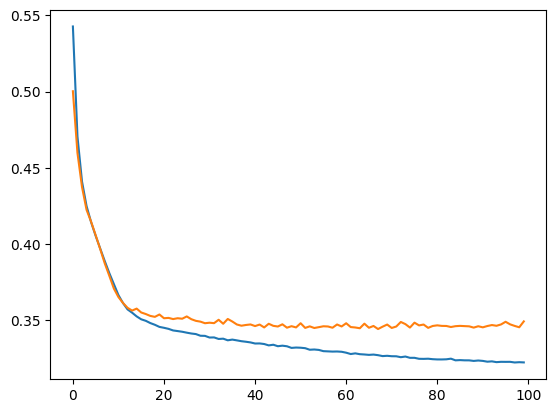

In [315]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()


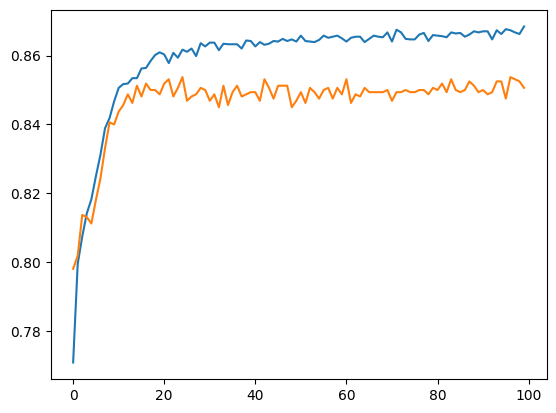

In [316]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()